# Profile Coherence as a Diagnostic Lens for Financial Asset Recommendation

## Setup

In [1]:
import sys
from pathlib import Path

ROOT = (
    Path("..").resolve()
    if Path(".").resolve().name == "notebooks"
    else Path(".").resolve()
)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.analysis.findings import (  # noqa: E402
    NotebookPaths,
    build_rq3_per_band_summary,
    export_figures_as_pdf,
    compute_rq4_paired_table,
    configure_matplotlib,
    load_eda_summary,
    load_rq2_artefacts,
    load_rq4_per_split,
    plot_rq1_discordance_distribution,
    plot_rq1_per_band_coherence,
    plot_rq1_self_discordance,
    plot_rq1_yearly_discordance,
    plot_rq2_forest,
    plot_rq3_per_band,
    plot_rq4_paired_deltas,
    plot_rq4_paired_win_rates,
    style_rq2_coefficient_table,
    style_rq3_main_results,
    style_rq3_per_band_summary,
    style_rq4_aggregate,
    style_rq4_paired_table,
)

configure_matplotlib()
PATHS = NotebookPaths.from_root(ROOT)
EDA_SUMMARY = load_eda_summary(PATHS.eda_directory)

## Profile Coherence Metric

### Pairwise discordance

- `src/utils/profile_coherence.py` puts customers and assets on the **same 4-point ordinal scale**:
    - Conservative = 0
    - Income = 1
    - Balanced = 2
    - Aggressive = 3
- **Customer band**:
    - Read from FAR-Trans's `riskLevel` column
    - Additional `is_predicted` flag for risk levels that are regression-imputed (`Predicted_*`)
    - Customers with `Not_Available` or missing `riskLevel` are excluded by assigning value of `None` for it's band
- **Asset band (hierarchical steps)**:
    1. Subcategory metadata first:
        - Mutual Funds subcategories:
            - Money Market -> Conservative
            - Bond/Bonds -> Income
            - Balanced -> Balanced
            - Equity/Large Cap -> Aggressive
        - Bond subcategories:
            - Government -> Conservative
            - Corporate -> Income
            - Other bonds - > Income (default)
    2. Volatility-quartile fallback for stocks:
        - A trailing 252-day annualised log-return std is computed per ISIN
        - The stock-only distribution gives `(q1, q2, q3)` and each stock is bucketed accordingly
    3. Balanced default:
        - Assets that fall through both rules (typically stocks without enough history) get Balanced
- **Pairwise discordance** then is `d(u, i) = |b_u - b_i| ∈ {0, 1, 2, 3}`
- A recommendation is **profile-coherent** iff `d ≤ 1`
- Strict variant `d == 0` is reported only as a sensitivity row

### Profile Coherence @k

- `src/utils/metrics.py` wraps the above into the `@k` aggregation:
    ```
    PC@k(u) = (1/k) · |{ i ∈ top_k(u) : d(u, i) ≤ 1 }|
    ```
- 3 implementation rules close the definition:
    1. **Truncation, not pad**:
        - A recommender returning fewer than `k` items is scored on what it returned
        - Replace `k` with the number of items recommended
    2. **Unclassifiable assets count as discordant**:
        - An `asset_id` missing from the band lookup contributes 0 to `coherent_count`
        - Should not occur due to the Balanced default
    3. **No-band customers contribute 0**:
        - Customers with `b_u = None` are excluded
        - Aggregate draws only on customers with a profile signal
- **PC@k for a split** is the unweighted mean of per-customer PC@k across eligible customers in that split
- Headline numerics then average over all splits

### Baseline Profile Coherence

- **Random baseline `pi(b)`** is computed directly from the asset-band distribution (`compute_random_baseline_per_band`):
    ```
    pi(b) = |{ i ∈ A : |b - b_i| ≤ 1 }| / |A|
    ```
- The closed-form expectation of PC@k under a uniformly random recommender per band
- For FAR-Trans:
    - Asset-band distribution `(190, 333, 105, 178)` of 806 assets
    - Over scale of `(Conservative, Income, Balanced, Aggressive)`
    - Results in `pi = (0.65, 0.78, 0.76, 0.35)`

### Profile Coherence - Lift @k

- **PC-lift@k** expresses per-user PC@k as a ratio against the band-conditional random baseline `pi(b_u)`:
    ```
    PC-lift@k(u) = PC@k(u) / pi(b_u)
    ```
- The baseline profile coherence is skewed
- 77.9% of assets span the tolerated set of (`Conservative + Income + Balanced`)
- Hence if a recommender just shoves Income funds at everyone, it will score well on raw PC@k for the majority of users (whose band tolerance includes `Income`)
- Dividing PC@k by `pi(b_u)` strips the band-specific easiness of the asset universe out of the metric; the resulting unit is `x` the band-conditional random rate rather than an absolute coherent share, so PC-lift values are commensurate across bands
- Lift = 1.0 implies the model matched the band-conditional random rate
- Lift > 1.0 implies the model beats the band-conditional random rate

## RQ1: Profile-discordance is prevalent and structural

**Question.** How prevalent is profile-discordance in observed FAR-Trans Buy transactions, and is it customer-level trait or transaction-level noise?

**Setup.** Each Buy transaction `(u, i)` is annotated with a customer band `b_u` and an asset band `b_i` using the rules described above. Recall that pairwise discordance is `d = |b_u - b_i|` and the transaction is profile-coherent under the default tolerance iff `d <= 1`.

Total scoreable Buys:      228,241
Coherent (d<=1) share:     81.4%
Strict-coherent (d=0):     34.1%
Mean profile discordance:  0.874 bands


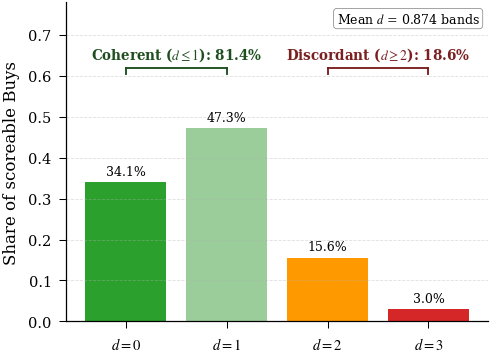

In [2]:
plot_rq1_discordance_distribution(EDA_SUMMARY)

**Insights.**
- Heavy tailed distribution
- Hence a typical violation is a one-band miss

Population discordance rate (per Buy):                 18.6%
Mean Buys per customer      (with a known band):       7.93
Fully coherent customers    (every Buy in tolerance):  64.4%
Fully discordant customers  (every Buy out of toler.): 17.2%


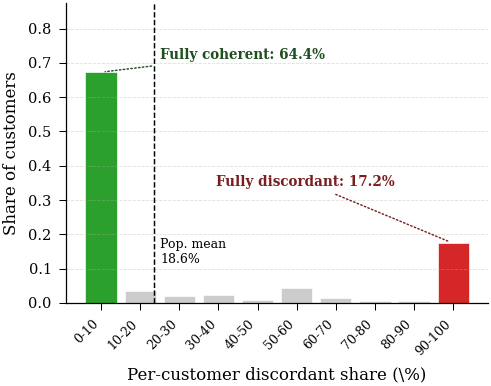

In [3]:
plot_rq1_self_discordance(EDA_SUMMARY)

**Insights.**
- The per-customer distribution is strongly bimodal piled at the two extreme 
- Profile-discordance is persistent within customers, not transaction-level noise, because the bimodal distribution shows customer shares piling up at 0% and 100% rather than clustering near the 19% population mean, which i.i.d. transaction-level noise cannot produce

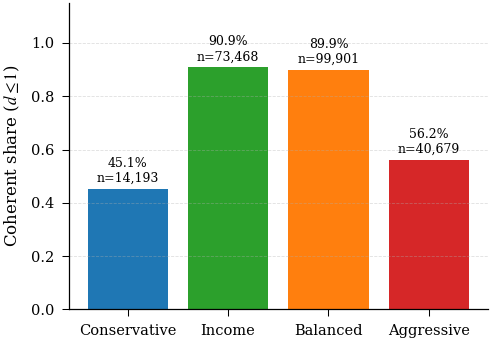

In [4]:
plot_rq1_per_band_coherence(EDA_SUMMARY)

**Insights.**
- Discordance is concentrated on the two ordinal extremes
- Conservative customers are coherent on only 45.1% of their Buys
- The rest are reach-for-yield purchases of riskier assets
- Aggressive customers are coherent on 56.2%
- Regression-toward-the-centre into safer assets
- The 2 centre bands (Income, Balanced) are roughly 90% coherent
- The U-shape supports the bimodality finding earlier

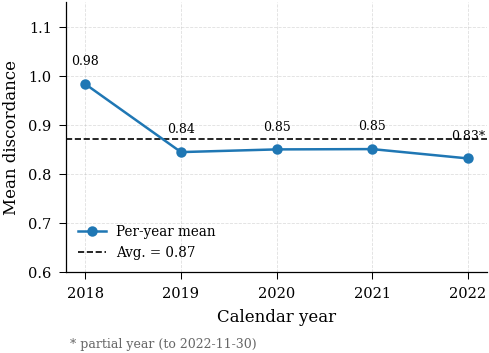

In [5]:
plot_rq1_yearly_discordance(EDA_SUMMARY)

**Insights.**
- Mean discordance is flat across the macro window
- 2019-2022 cluster within 0.02 bands
- From 2019 onwards the line is essentially horizontal
- Pattern is not driven by a market regime
- **Caveat (2018 outlier hypothesis):**
    - 2018 sits higher (0.98 bands) but contributes a small slice of the dataset
    - MiFID II came into force on 2018-01-03, the exact start of FAR-Trans
    - The 2018 elevation seems to be consistent with a transition effect:
        - Risk profiles were being captured for the first time under the new framework
        - While customers were still trading under pre-MiFID habits formed without a declared band
    - By 2019 the system had a year of profile-aware history and the line settles
    - Possible future extension of work to confirm the above hypothesis


## RQ1 Findings Summary

Profile-discordance in FAR-Trans is:

- **Prevalent**:
    - 18.6% of 228,241 scoreable Buys violate the declared MiFID band by 2 or more steps
- **Customer-level, not transaction-level noise**:
    - The per-customer discordant-share distribution is sharply bimodal at 0% and 100% rather than clustering near the 19% population mean, which i.i.d. transaction-level noise cannot produce
    - Further supported by the U-shape per-band coherence share which shows that discordance is structurally concentrated on the ordinal extremes
- **Stable across the macro window**:
    - 2019-2022 cluster within 0.02 bands of each other, so the pattern is not regime-driven
    - The 2018 higher value is hypothesised as a MiFID II transition effect (future work)

## RQ2: Profile-coherent buys earn higher realised return


**Question.** Conditional on asset volatility, customer segment, and year, do profile-discordant transactions earn lower realised 6-month return than profile-coherent ones?

**Data construction.**
- Each Buy is joined to a start price at trade date and an end price 6 months later
- Both prices use a backward-asof match against the close-price series with a 7-day tolerance
  - Picks the most recent trading-day close within 7 calendar days
  - Handles weekends and holidays without future leakage
  - Drops any row where the gap exceeds a week
- Realised return: `realised_return = (end_price - start_price) / start_price`

**Model.**

```
realised_return ~ is_coherent + asset_volatility + C(customer_type) + C(year)
```

- **Dependent variable (Y)** = `realised_return`
  - 6-month forward return on the Buy
  - What the regression is trying to *explain*
- **Variable of interest (X)** = `is_coherent`
  - Binary flag: `1` if `d <= 1`, else `0`
  - Coefficient on this term is the headline result for RQ2
  - The only term we test substantively
- **Controls (Z)** = `asset_volatility`, `C(customer_type)`, `C(year)`
  - Hold constant the natural confounders of returns: *what* was bought, *who* bought it, *when*
  - Lets the `is_coherent` coefficient reflect a coherence-specific effect, not a "low-vol assets won" or "2020 rebound" story in disguise
- **Standard errors.** Cluster-robust on `customerID`
  - Each customer makes ~8 Buys on average, sharing unobserved customer-level shocks (account constraints, advisor channel, persistent risk attitude)
  - Within-customer residuals are correlated, so OLS i.i.d. is too strong
  - Cluster-robust SE allows arbitrary within-customer correlation while keeping independence across customers
  - Point estimates unchanged; SEs typically grow because effective sample size shifts toward the number of *customers* rather than *Buys*
  - Treats customers, not individual Buys, as the independent units of variation
- **Test choice.** Two-sided Wald tests, `alpha = 0.05` (95% confidence)
  - No directional prior on the controls (volatility, year, customer segment), so two-sided is the appropriate default
  - Keeps the analysis agnostic for `is_coherent` too: a negative coefficient with `p < 0.05` would falsify the hypothesis just as decisively as a positive one

In [6]:
COEFFICIENTS = load_rq2_artefacts(PATHS.rq2_directory)
style_rq2_coefficient_table(COEFFICIENTS)

,term,estimate,std_error,ci,p_value,meaning
0,Intercept,-0.0471,0.0141,"[-0.0746, -0.0195]",8.1e-04,"Baseline = Inactive customer, 2018, all numeri..."
1,is_coherent,+0.0294,0.0040,"[+0.0215, +0.0372]",2.3e-13,"Coherence premium after controlling for vol, s..."
2,asset_volatility,-0.1025,0.0165,"[-0.1349, -0.0701]",5.5e-10,Return penalty per 1.0 unit of annualised vol ...
3,C(customer_type)[T.Legal Entity],+0.0154,0.0486,"[-0.0798, +0.1106]",0.7512,Segment effect vs Inactive reference
4,C(customer_type)[T.Mass],+0.0011,0.0132,"[-0.0248, +0.0269]",0.9362,Segment effect vs Inactive reference
5,C(customer_type)[T.Premium],+0.0058,0.0135,"[-0.0206, +0.0322]",0.6671,Segment effect vs Inactive reference
6,C(customer_type)[T.Professional],+0.0247,0.0169,"[-0.0084, +0.0578]",0.1434,Segment effect vs Inactive reference
7,C(year)[T.2019],+0.1759,0.0129,"[+0.1507, +0.2012]",1.4e-42,Calendar effect vs 2018 reference (pre-COVID e...
8,C(year)[T.2020],+0.2107,0.0061,"[+0.1986, +0.2227]",6.2e-259,Calendar effect vs 2018 reference (COVID rebound)
9,C(year)[T.2021],+0.0754,0.0053,"[+0.0651, +0.0858]",4.1e-46,Calendar effect vs 2018 reference (continued p...


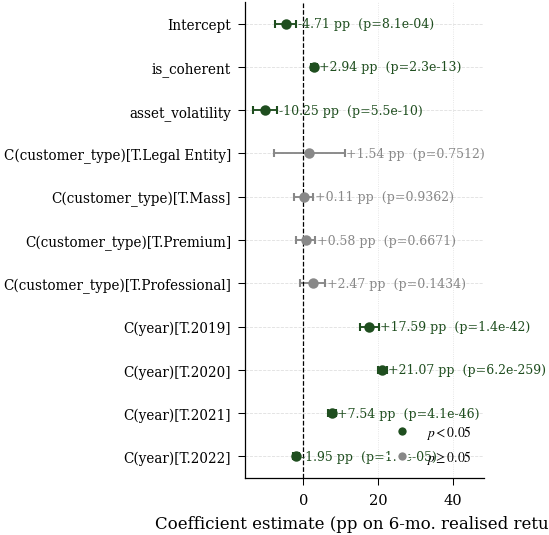

In [7]:
plot_rq2_forest(COEFFICIENTS)

**Insights.**

- **Intercept (reject H0)**:
    - Reference cell: Inactive customer, 2018, `asset_volatility = 0`, `is_coherent = 0`
    - Significance just tells us this baseline differs from zero
    - The 2018 reference year was weak (the year dummies for 2019, 2020, 2021 are all strongly positive vs 2018)
    - Baseline is a *discordant* Buy on top of that, so the predicted return lands at -4.71 pp
- **`is_coherent` (reject H0)**:
    - Profile-coherent Buys earn +2.94 pp more 6-month return than profile-discordant ones
    - Conditional on volatility, customer segment, and year
    - Our prior belief is that "regulatory coherence will impose a return tax" (coefficient < 0)
    - Prior is **falsifies** since the direction is positive and statistically significant
- **`asset_volatility` (reject H0)**:
    - Each +1.0 unit of annualised volatility maps to -10.3 pp / 6-month return
    - **Why the sign is negative?**:
        - In the 2019 to 2022 window, lower-volatility assets outperformed higher-volatility ones
        - The 2022 rate shock (see year FE below) hit high-beta and growth names hardest
        - While defensive and bond-like assets held up better
        - Window-specific, not a structural claim about long-run risk premia
- **Year fixed effects (reject H0 for all)**:
    - **2019:**. Equity recovery from the late-2018 selloff
    - **2020:**. COVID V-shaped rebound
    - **2021:**. Continued post-COVID recovery on low rates, ahead of the late-2021 rate-hike fears
    - **2022:**. Rate-shock and bond drawdown year. Aggressive Fed hikes hit fixed income
    - **Why these matter**:
        - They absorb the calendar variance so the other coefficients are not confounded by which year the Buy fell in
        - The shape (2020 strongly positive, 2022 negative) confirms the regime tilt of the sample window
        - Corroborates the negative `asset_volatility` sign above
- **Customer-type dummies (Fail to reject H0 for all)**:
    - Underlying data give no evidence of a customer-type return effect
    - For Mass and Premium any real effect is small
    - Inconclusive for Professional and Legal Entitys
    - **Link to RQ1**:
        - Combined with the bimodality finding
        - This implies customer segmentation does not capture the persistent customer-level discordance trait either
- **Profile coherence is robust to the controls (wrap-up on `is_coherent`)**:
    - Raw slice gap (`mean(coherent) - mean(discordant)`, no regression): **+3.31 pp**
    - Conditional estimate after `asset_volatility + C(customer_type) + C(year)`: **+2.94 pp**
    - Controls absorb only +0.37 pp jointly, i.e. **~11% of the unconditional gap**
    - **Caveat:**
        - Rules out vol, segment, and year as the hidden cause
        - Does not rule out other unobserved confounders (e.g. financial literacy, etc.)

## RQ2 Findings Summary

The model `realised_return ~ is_coherent + asset_volatility + C(customer_type) + C(year)`, fit on 208,029 priced Buys with cluster-robust SE on `customerID`, yields:

- **Coherence premium (variable of interest, `is_coherent`)**:
    - Our prior belief that "regulatory coherence will impose a return tax" (coefficient < 0) is **falsified**
    - The direction is positive and statistically significant
    - The association is observational, but the sign motivates the model-side investigations in RQ3 and RQ4
- **Robust to controls**:
    - ~89% of the +3.31 pp raw slice gap survives the controls
    - Only ~0.4 pp is absorbed by volatility, segment, and year
    - The +2.94 pp residual is therefore not a vol / segment / year confound in disguise
    - Other unobserved confounders are not ruled out
- **Controls do real diagnostic work**:
    - All four year dummies reject H0
    -  `asset_volatility` coefficient is -0.103
        - low-volatility assets outperformed in the 2019 to 2022 regime
- **Customer segmentation contributes no detectable return signal**:
    - All four `C(customer_type)` dummies fail to reject H0
    - Combined with the RQ1 bimodality finding, this implies that customer segmentation does not capture the persistent customer-level trait driving discordance

## RQ3: Both FAR-Trans baselines under-serve declared-band coherence

**Question.** Where do the FAR-Trans baselines (Random Forest, LightGCN) sit on the PC@10 axis, and does any baseline match or exceed the band-conditional random baseline `pi(b)` for every declared band?

**Setup.**
- Each baseline is tuned on its FAR-Trans primary metric (LightGCN: nDCG@10, Random Forest: ROI@10) over a grid of 8/12 trials respectively
- The tuned configuration is evaluated on 69 monthly temporal splits between Aug 2019 and Apr 2025
- Per-customer PC@10 is computed for every (customer, split, model) cell, then averaged within each (declared_band, model) combination
- Per-band lift = mean PC@10 / random baseline `pi(b)`

In [8]:
style_rq3_main_results(PATHS.rq3_decomp_directory)

,Model,Best trial,Primary metric,nDCG@10,ROI@10 (mo.),Recall@10,PC@10,PC-lift@10
0,LightGCN,eb788_00006,average_ndcg,0.330,-0.0054,0.495,0.794,1.171
1,Random Forest,df0bd_00008,average_roi,0.019,+0.0142,0.036,0.667,1.060


**Insights.**

- LightGCN takes the top spot on ranking-quality metrics (nDCG@10 = 0.330, Recall@10 = 0.495, PC@10 = 0.794) but loses on realised return (ROI = -0.5%/mo)
- Random Forest takes the top spot on ROI (+1.4%/mo) but ranks near random on nDCG (0.019) and Recall (0.036)
- **Both models look fine on the aggregate PC axis**:
    - LightGCN PC-lift@10 = 1.17x random
    - Random Forest PC-lift@10 = 1.06x random
    - Both above 1.0
- But aggregate PC averages across customer bands with very different `pi(b)` baselines
- So the aggregate hides which bands are actually being served
- The per-band table below decomposes that

In [9]:
RQ3_PER_BAND_SUMMARY, PI_SERIES = build_rq3_per_band_summary(
    PATHS.rq3_panel_directory, EDA_SUMMARY
)
style_rq3_per_band_summary(RQ3_PER_BAND_SUMMARY)

,band_label,model_display,n_observations,mean_pc,pi_b,lift
0,Conservative,LightGCN,5348,0.484349,0.648883,0.746
1,Income,LightGCN,45142,0.883811,0.779156,1.134
2,Balanced,LightGCN,61181,0.890347,0.764268,1.165
3,Aggressive,LightGCN,25367,0.472728,0.351117,1.346
4,Conservative,Random Forest,5348,0.338837,0.648883,0.522
5,Income,Random Forest,45142,0.543669,0.779156,0.698
6,Balanced,Random Forest,61181,0.785746,0.764268,1.028
7,Aggressive,Random Forest,25367,0.661269,0.351117,1.883


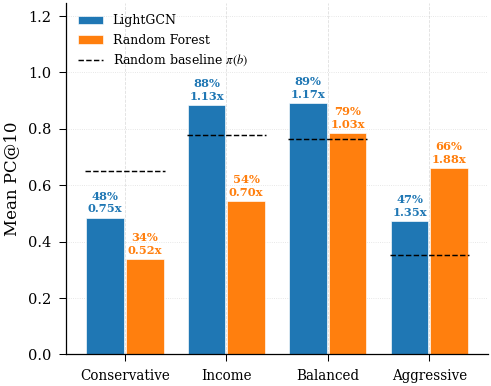

In [10]:
plot_rq3_per_band(RQ3_PER_BAND_SUMMARY, PI_SERIES)

**Insights.**

- **Which (model, band) combinations beat the random baseline `pi(b)`**:
    - LightGCN
        - Clears `pi(b)` on Income (lift 1.13x), Balanced (1.17x), and Aggressive (1.35x)
        - Falls below `pi(b)` on Conservative (0.75x)
    - Random Forest
        - Clears `pi(b)` on Balanced (1.03x) and Aggressive (1.88x)
        - Falls below `pi(b)` on Conservative (0.52x) and Income (0.70x)
    - Neither model uses band labels or a band-aware loss
    - Profile coherence by band is a passive byproduct of the training data, not a controlled output
    - Lift > 1 occurs where the model's training-induced asset preference happens to overlap a band's tolerance window
    - Lift < 1 where it does not
- **Shape of lift across the band axis**:
    - LightGCN lift: 0.75 -> 1.13 -> 1.17 -> 1.35 (Conservative -> Income -> Balanced -> Aggressive)
    - Random Forest lift: 0.52 -> 0.70 -> 1.03 -> 1.88 (Conservative -> Income -> Balanced -> Aggressive)
    - For both models, lift rises monotonically with the customer's declared band
    - Both models' recommended-asset distributions skew toward higher-risk bands
    - LightGCN's range is flatter than Random Forest
        - Unlike Random Forest, LightGCN's per-user embeddings let it tailor picks per customer via the user-item buy graph, so each customer's top-k partly shifts toward their own tolerance window.
- **Customer footprint of the lift < 1 cases**:
    - 28,770 banded customers in total
    - Band shares: Conservative 19.7%, Income 41.1%, Balanced 29.8%, Aggressive 9.3%
    - LightGCN under-serves the 19.7% Conservative segment
    - Random Forest under-serves 60.9% (Conservative + Income combined)
- **Asset-side structure of `pi(b)`**:
    - Aggressive has the lowest value of 0.35
    - Income and Balanced have the highest value of 0.78 and 0.76
    - Bar to beat random on Aggressive customers is the lowest of any band
        - Hence Aggressive's high lift on both models is partly mechanical
        - A model whose recommendations skew higher-vol clears the 0.35 bar easily


## RQ3 Findings Summary

Locating the two FAR-Trans baselines (Random Forest, LightGCN) at their primary-metric optima on the PC@10 axis, with a band-conditional random baseline `pi(b)`:

- **Per-band failures are model-specific, not symmetric**:
    - LightGCN is sub-random on Conservative only (lift 0.75x); under-serves 19.7% of banded customers
    - Random Forest is sub-random on Conservative (0.52x) AND Income (0.70x); under-serves 60.9% of banded customers
    - On Balanced and Aggressive both models clear `pi(b)`
- **Both models skew toward higher-risk asset bands**:
    - Lift rises monotonically Conservative -> Income -> Balanced -> Aggressive for both
    - LightGCN's flatter range reflects per-customer differentiation borrowed from the user-item buy graph
- **Aggressive's high lift is partly mechanical**:
    - `pi(b)` on Aggressive is the lowest of any band (0.35) because most assets sit outside {Balanced, Aggressive}
    - A model whose recommendations skew higher-vol clears that bar with little effort
- **Coherence by band is a passive byproduct of training, not a controlled output**:
    - Neither model has band labels in training or a band-aware loss
    - Lift > 1 occurs only where the model's training-induced asset preference happens to overlap a band's tolerance window
    - Motivates RQ4: a stratified, profile-coherent architecture aims to make coherence an objective rather than an accident

## RQ4: Stratification + profile-coherent loss closes the per-band coverage deficit

**Question.** Can a stratified, profile-coherent LightGCN extension (one sub-model per declared MiFID risk band, trained with a profile-coherent margin loss) improve PC@10 over the global LightGCN baseline, and at what cost to nDCG, Recall, and ROI?

**Setup.**
- Two trials, both inheriting the RQ3 best LightGCN trial's backbone hyperparameters:
    - `embedding_dimension = 64`
    - `number_of_layers = 3`
    - `learning_rate = 1e-3`
    - `weight_decay = 1e-5`
    - `keep_probability = 0.6`
    - `number_of_epochs = 50`
    - `batch_size = 1024`
- **`stratified_lambda_0.0`** (ablation):
    - Four band-stratified sub-models trained independently
    - BPR loss only
- **`stratified_lambda_1.0`** (treatment):
    - Four band-stratified sub-models with an added profile-coherent margin loss
    - Loss term: `softplus(score_discordant - score_coherent)`
    - Weight: `lambda = 1`
- Both trials evaluated on the same 69 splits as RQ3
- So per-split deltas are paired against the global LightGCN baseline (`eb788_00006`)

**Choice of backbone.**
- LightGCN trains with a differentiable loss and carries per-customer embeddings, so the coherence margin can be added on top
- Random Forest has no customer signal in its training objective (asset-level technical indicators only)

**Loss composition.**
- The profile-coherent margin is **added on top of** the existing BPR ranking loss, not a replacement
- Total: `total_loss = bpr_loss + weight_decay * l2 + lambda * coherence_loss`
- Setting `lambda = 0` zeroes the coherence term and reduces the model to stratified BPR (the ablation)
- Both trials keep BPR as the primary ranking signal
- Only the treatment trial activates the coherence term

In [11]:
RQ4_PER_SPLIT = load_rq4_per_split(
    PATHS.rq4_baseline_directory, PATHS.rq4_results_directory
)
style_rq4_aggregate(RQ4_PER_SPLIT)

Aggregate metrics: mean across 69 evaluation splits, per configuration


,Configuration,nDCG@10,ROI@10 (mo.),Recall@10,PC@10,PC-lift@10
0,LightGCN baseline (RQ3),0.3295,-0.0054,0.4946,0.7940,1.171
1,"Stratified, λ=0 (ablation)",0.3317,-0.0073,0.5009,0.8215,1.189
2,"Stratified, λ=1 (treatment)",0.3094,-0.0071,0.4671,0.9182,1.396


In [12]:
RQ4_PAIRED = compute_rq4_paired_table(RQ4_PER_SPLIT)
style_rq4_paired_table(RQ4_PAIRED)

mean_delta                                             \
metric               PC-lift@10     PC@10 ROI@10 (mo.) Recall@10   nDCG@10   
contrast                                                                     
λ=0 vs baseline        +0.01875  +0.02745     -0.00191  +0.00626  +0.00222   
λ=1 vs baseline        +0.22594  +0.12422     -0.00175  -0.02750  -0.02011   
λ=1 vs λ=0 (PC-loss)   +0.20719  +0.09676     +0.00015  -0.03376  -0.02233   

                       win_rate                                       
metric               PC-lift@10 PC@10 ROI@10 (mo.) Recall@10 nDCG@10  
contrast                                                              
λ=0 vs baseline             90%  100%          28%       72%     57%  
λ=1 vs baseline            100%  100%          33%        7%      7%  
λ=1 vs λ=0 (PC-loss)       100%  100%          58%        0%      0%

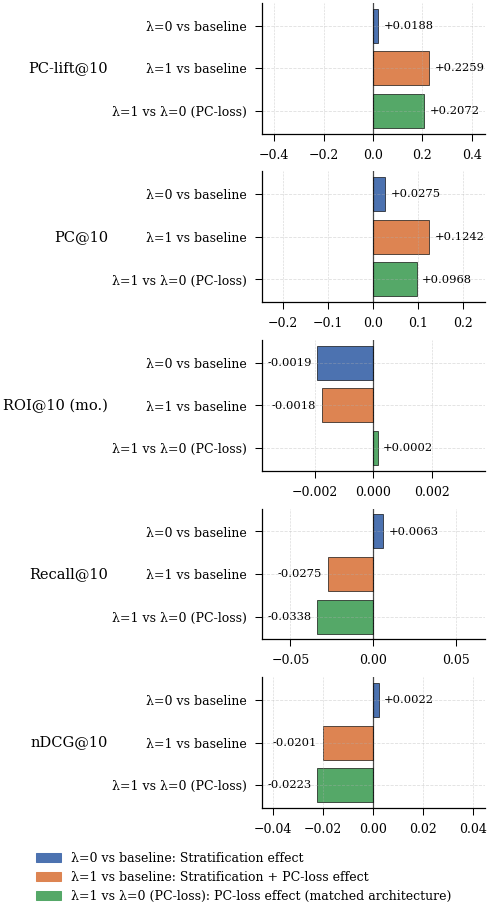

In [13]:
plot_rq4_paired_deltas(RQ4_PAIRED)

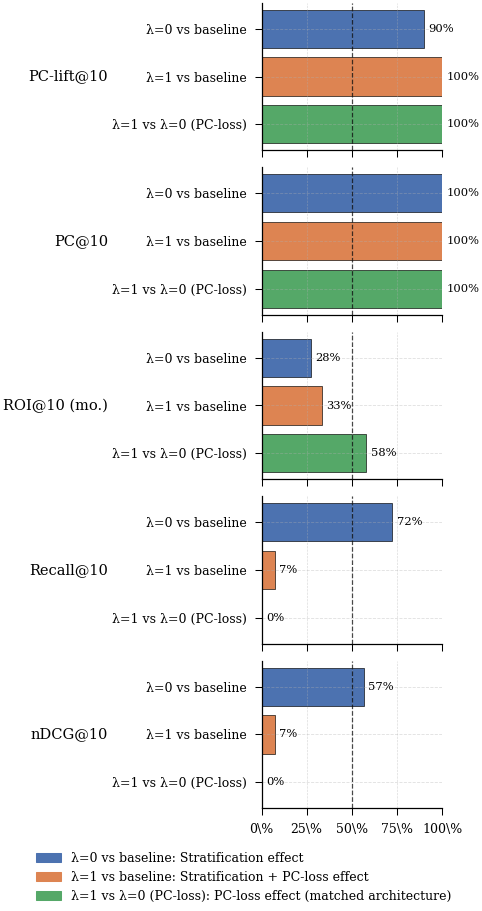

In [14]:
plot_rq4_paired_win_rates(RQ4_PAIRED)

**Insights.**

- **The treatment (λ=1) wins PC@10 universally and by a large margin**:
    - Aggregate PC@10 climbs from 0.794 (baseline) to 0.918 (+12.4 pp)
    - PC-lift@10 climbs from 1.17x to 1.40x random
    - Win rate is 100% on both PC@10 and PC-lift@10
        - λ=1 beats the baseline on every single one of the 69 splits
- **Stratification alone (λ=0) is essentially free signal**:
    - λ=0 vs baseline: PC@10 +0.027 (100% wins), Recall +0.006 (72% wins), nDCG +0.002 (57% wins)
    - Splitting the model by band lifts band-coverage even without the PC-loss, with no ranking-quality cost
    - Contributes ~22% of the full λ=1 PC@10 gain (+2.7 pp out of +12.4 pp)
- **The PC-loss is the expensive but high-payoff piece**:
    - λ=1 vs λ=0: PC@10 +0.097 (100% wins), Recall -0.034 (0% wins), nDCG -0.022 (0% wins)
    - Buys +9.7 pp PC@10 at the bounded cost of ~2 pp nDCG and ~3 pp Recall
    - Contributes ~78% of the full λ=1 PC@10 gain (+9.7 pp out of +12.4 pp)
    - The gain decomposes cleanly
        - Stratification supplies the cheap quarter, the PC-loss supplies the rest
- **Aggregate ROI is essentially flat, and the small penalty is not from the PC-loss**:
    - Full intervention (λ=1 vs baseline): ROI -0.002 pp/mo (33% wins), a tiny drop
    - Stratification alone (λ=0 vs baseline): ROI -0.002 pp/mo (28% wins), same drop
    - PC-loss alone (λ=1 vs λ=0): ROI +0.0001 pp/mo (58% wins), indistinguishable from noise
    - So the small aggregate ROI cost lives in stratification, not in the coherence loss

## RQ4 Findings Summary

A stratified, profile-coherent LightGCN extension (four band sub-models trained with `total_loss = bpr_loss + weight_decay * l2 + lambda * coherence_loss`), evaluated against the RQ3 LightGCN baseline on 69 monthly splits:

- **The treatment (λ=1) wins PC@10 universally**:
    - Aggregate PC@10 climbs from 0.794 (baseline) to 0.918 (+12.4 pp); PC-lift@10 from 1.17x to 1.40x random
    - Win rate is 100% on both PC@10 and PC-lift@10 across the 69 splits, so the improvement is robust across the evaluation window rather than driven by a handful of favourable splits
- **The PC@10 gain decomposes cleanly into two pieces**:
    - **Stratification alone (λ=0)**: +2.7 pp PC@10 (~22% of the full gain), with no ranking-quality cost (Recall +0.006, nDCG +0.002, both indistinguishable from noise). Essentially free signal
    - **PC-loss (λ=1 vs λ=0)**: +9.7 pp PC@10 (~78% of the full gain) at a bounded cost of ~2 pp nDCG and ~3 pp Recall. The expensive but high-payoff piece
- **ROI penalty is essentially zero, and the small drop is not from the coherence loss**:
    - Full intervention (λ=1 vs baseline): ROI -0.002 pp/mo (33% wins); negligible
    - Stratification alone (λ=0 vs baseline): ROI -0.002 pp/mo (28% wins); same drop, so the cost lives in stratification, not in the coherence pressure
    - PC-loss alone (λ=1 vs λ=0): ROI +0.0001 pp/mo (58% wins); indistinguishable from noise
- **Closes the per-band coverage deficit from RQ3 without paying on aggregate return**:
    - Combined with RQ2's customer-side coherence-return premium, the result confirms that the regulatory and economic objectives are not in structural conflict on FAR-Trans
    - A recommender can be made meaningfully more profile-coherent without giving up the return story the data says is already there

## Conclusion

The thesis frames **profile coherence** as a diagnostic lens for the FAR-Trans recommendation problem, and assembles the four research questions into a single diagnostic-to-remedy chain:

- **RQ1** establishes that the diagnostic axis is real and structural at the customer level, not transaction-level noise
- **RQ2** removes the economic objection to optimising for coherence: the "regulatory return tax" prior is observationally falsified
- **RQ3** locates the existing FAR-Trans baselines on the coherence axis and shows that both under-serve specific declared bands in ways the aggregate metrics hide
- **RQ4** demonstrates that a stratified, profile-coherent LightGCN extension closes the per-band coverage deficit at no aggregate ROI cost, with the gain decomposing cleanly into a free stratification component and a bounded-cost PC-loss component

**Headline contribution.** The regulatory objective (MiFID-aligned band coherence) and the economic objective (realised return) are not in structural conflict on FAR-Trans. A recommender can be made meaningfully more profile-coherent while keeping the return story the data already supports, which reframes coherence as an architectural choice rather than a tradeoff to be managed post-hoc.

**Position in the broader literature.** The work treats compliance not as a post-hoc filter applied downstream of a ranking model, but as a training-time objective expressible as an ordinal distance on a customer-asset metric pair. The stratification + margin-loss template generalises naturally to other suitability-style constraints (concentration limits, leverage caps, ESG bands) that share the same ordinal structure.

## Limitations

- **RQ2 is observational, not causal**: unobserved confounders (financial literacy, advisor channel, account constraints, prior portfolio composition) are not ruled out by the volatility / segment / year controls
- **The 2018 elevation in mean discordance** is hypothesised as a MiFID II transition effect but is not directly tested against a pre-MiFID counterfactual
- **The coherence metric carries design choices**: the tolerance `d <= 1` is set rather than derived, the metric binarises a 4-point ordinal distance rather than treating it continuously, and the asset-band assignment is a hierarchical heuristic (subcategory -> volatility quartile -> Balanced default) that is not externally validated against an independent labelling
- **Architectural scope is narrow**: only LightGCN is extended with the stratified + PC-loss treatment; sequential, transformer-based, and content-based recommenders are not tested
- **Single operating point**: `lambda = 1` is one point on a Pareto frontier between PC and ranking-quality metrics; the full frontier is not mapped
- **Hyperparameter inheritance**: the RQ4 intervention inherits backbone hyperparameters from the RQ3 best LightGCN trial rather than being re-tuned end-to-end, so the reported gains are a lower bound on what re-tuning could achieve
- **Single-dataset, single-jurisdiction**: results are on FAR-Trans under MiFID II's 4-band scale; generalisation to other jurisdictions, longer windows, alternative band definitions, or other asset universes is not established
- **Evaluation gap between RQ2 and RQ4**: RQ2 measures realised return on executed Buys, RQ4 measures forward return on top-k recommended slates that may never be acted on. The two ROI quantities are not the same object, so the RQ2 coherence premium and the RQ4 null aggregate-ROI effect are not directly comparable

## Potential Future Work

- **Pareto frontier sweep**: vary `lambda` across a range and map the (PC@10, nDCG, Recall, ROI) frontier so operators can pick an explicit operating point rather than the single `lambda = 1` reported here
- **Causal identification of the RQ2 coherence premium**: instrumental-variable or natural-experiment designs (e.g. exploiting MiFID II's 2018 introduction as a regulatory shock) to test whether the coherence-return association survives in a causal sense
- **Continuous coherence formulation**: replace the binary `d <= 1` indicator with a continuous penalty in `d` so the loss penalises a 3-band miss more than a 2-band miss
- **Time-varying bands**: customers' MiFID profiles drift over time; incorporate band history as a sequence rather than a snapshot input
- **Portfolio-level coherence**: extend the metric from per-recommendation coherence to portfolio-level allocation coherence, which is closer to how MiFID suitability is actually assessed in practice

## Export figures as PDF

Run the cell below to write every figure shown above to `submission/paper/figures/` as a standalone PDF for direct inclusion in the LaTeX paper. Skip it if you only want the inline previews.

In [15]:
pdf_paths = export_figures_as_pdf(
    output_directory=ROOT / "submission/paper/figures",
    eda_summary=EDA_SUMMARY,
    paths=PATHS,
)
for p in pdf_paths:
    print(p.relative_to(ROOT))

Total scoreable Buys:      228,241
Coherent (d<=1) share:     81.4%
Strict-coherent (d=0):     34.1%
Mean profile discordance:  0.874 bands
Population discordance rate (per Buy):                 18.6%
Mean Buys per customer      (with a known band):       7.93
Fully coherent customers    (every Buy in tolerance):  64.4%
Fully discordant customers  (every Buy out of toler.): 17.2%
submission/paper/figures/rq1_discordance_distribution.pdf
submission/paper/figures/rq1_self_discordance.pdf
submission/paper/figures/rq1_per_band_coherence.pdf
submission/paper/figures/rq1_yearly_discordance.pdf
submission/paper/figures/rq2_coefficient_forest.pdf
submission/paper/figures/rq3_per_band_pc.pdf
submission/paper/figures/rq4_paired_deltas.pdf
submission/paper/figures/rq4_paired_win_rates.pdf
